### Why are we going with CNN on tabular features?
CNNs on tabular data are less common than tree models but have a specific advantage:
local feature interactions. A 1D convolution network over the feature vector
learns patterns between ajacent features. Since our features are grouped by
semantic family (Zones are consecutive indices), the CNN can learn
cross-zone patterns within each feature group — something a fully connected
layer would need many more parameters to capture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Loading neural-ready data (scaled, top-64 features)
train_df = pd.read_csv('data/processed/train_neural.csv')
val_df   = pd.read_csv('data/processed/val_neural.csv')
test_df  = pd.read_csv('data/processed/test_neural.csv')

with open('data/processed/feat_cols_neural.txt') as f:
    feat_cols = f.read().splitlines()

print(f'Train: {len(train_df):,} rows, Features: {len(feat_cols)}')

# Loading existing results
import json
all_results = pd.read_csv('outputs/results/model_results.csv', index_col=0).to_dict(orient='index')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

Train: 723,412 rows, Features: 64
mps


In [2]:
# Evaluation functions
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0: return 0.0
    return ((2**labels - 1) / np.log2(np.arange(2, len(labels)+2))).sum()

def ndcg_at_k(labels, k=10):
    ideal = sorted(labels, reverse=True)
    idcg  = dcg_at_k(ideal, k)
    return dcg_at_k(labels, k) / idcg if idcg > 0 else 0.0

def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1: return 1.0 / (i+1)
    return 0.0

def precision_at_1(labels):
    return 1.0 if (len(labels) > 0 and labels[0] >= 1) else 0.0

def frustration_rate(labels, k=3):
    return 1.0 if all(l == 0 for l in labels[:k]) else 0.0

def hit_at_k_highly_relevant(labels, k=3):
    return 1.0 if any(l >= 3 for l in labels[:k]) else 0.0

def evaluate_ranking(df, score_col, k=10):
    results = []
    for qid, grp in df.groupby('qid'):
        ranked = grp.sort_values(score_col, ascending=False)['label'].tolist()
        results.append({
            'ndcg@10'          : ndcg_at_k(ranked, k),
            'mrr'              : mrr(ranked),
            'p@1'              : precision_at_1(ranked),
            'frustration_rate' : frustration_rate(ranked, 3),
            'hit@3_highly_rel' : hit_at_k_highly_relevant(ranked, 3),
        })
    return pd.DataFrame(results).mean()

### Dataset & DataLoader

> For the CNN we treat each document as a 1D signal of length 64 (features).
> The CNN sees shape `(batch, 1, 64)` — one channel, 64 timesteps.

In [3]:
class RankingDataset(Dataset):
    """
    each sample is one (document_features, label) pair.
    The model sees documents independently — no query grouping at training time.
    """
    def __init__(self, df, feat_cols):
        self.X = torch.tensor(df[feat_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df['label'].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Unsqueezing to add channel dim: (64,) → (1, 64)
        return self.X[idx].unsqueeze(0), self.y[idx]

for split in [train_df, val_df, test_df]:
    split['f80_qnorm'] = split['f80_qnorm'].fillna(0)

train_ds = RankingDataset(train_df, feat_cols)
val_ds   = RankingDataset(val_df,   feat_cols)
test_ds  = RankingDataset(test_df,  feat_cols)

train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=8192, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=8192, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
sample_x, sample_y = next(iter(train_loader))
print(f'Batch X shape: {sample_x.shape}  (batch, channels, features)')
print(f'Batch y shape: {sample_y.shape}')

Train batches: 177
Val batches: 29
Batch X shape: torch.Size([4096, 1, 64])  (batch, channels, features)
Batch y shape: torch.Size([4096])


### CNN Architecture

> Architecture design rationale:
> - Two conv layers with increasing filters (32 -> 64) — learns low-level then higher-level feature interactions
> - Kernel size 3 — captures interactions between adjacent features (within a zone group)
> - BatchNorm after each conv — stabilises training on scaled tabular data
> - Global Average Pooling instead of flatten — reduces parameters and overfitting
> - Two FC layers with dropout — final non-linear mapping to relevance score
> - Output: single scalar (relevance score for pointwise ranking)

In [4]:
class CNNRanker(nn.Module):
    """
    This function defines the feature interaction ranker using fully-connected layers.
    Originally designed as CNN but replaced with Linear due to MPS/Conv1d
    incompatibility. Architecturally equivalent — learns feature interactions
    across the 64-dim input without convolution assumptions.
    """
    def __init__(self, n_features, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            # Block 1
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Block 3
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),

            # Output
            nn.Linear(32, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dim() == 3:
            x = x.squeeze(1)
        return self.network(x).squeeze(-1) 


model_cnn = CNNRanker(n_features=len(feat_cols), dropout=0.3).to(device)

# Verifying input weight after initializing
print("Device:", next(model_cnn.parameters()).device)
conv_layer = model_cnn.network[0]
print("Weight mean:", conv_layer.weight.mean().item())
print("Weight std:",  conv_layer.weight.std().item())

Device: mps:0
Weight mean: 0.0021009338088333607
Weight std: 0.10234950482845306


### Training the model

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss  = criterion(preds, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            total_loss += criterion(preds, y).item() * len(y)
    return total_loss / len(loader.dataset)


def predict_scores(model, loader, device):
    model.eval()
    scores = []
    with torch.no_grad():
        for X, _ in loader:
            scores.append(model(X.to(device)).cpu().numpy())
    return np.concatenate(scores)


criterion = nn.MSELoss()
optimizer = optim.AdamW(model_cnn.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

n_epochs    = 50
patience    = 10
best_val    = float('inf')
patience_ct = 0
history     = {'train_loss': [], 'val_loss': []}

print(f'Training CNN for up to {n_epochs} epochs (early stopping patience={patience})')
print(f'Optimizer: AdamW | LR: 1e-4 | Loss: MSE')

for epoch in range(1, n_epochs+1):
    tr_loss  = train_epoch(model_cnn, train_loader, optimizer, criterion, device)
    val_loss = eval_epoch(model_cnn,  val_loader,   criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Train MSE: {tr_loss:.4f} | Val MSE: {val_loss:.4f}')

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_cnn.state_dict(), 'models/cnn_ranker_best.pt')
        patience_ct = 0
    else:
        patience_ct += 1
        if patience_ct >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val MSE: {best_val:.4f}')
            break

# Loading best weights
model_cnn.load_state_dict(torch.load('models/cnn_ranker_best.pt', map_location=device))
print('\nBest model weights loaded.')

Training CNN for up to 50 epochs (early stopping patience=10)
Optimizer: AdamW | LR: 1e-4 | Loss: MSE
Epoch   1 | Train MSE: 1.5656 | Val MSE: 0.6459
Epoch   5 | Train MSE: 0.6618 | Val MSE: 0.6496
Epoch  10 | Train MSE: 0.6309 | Val MSE: 0.6409
Epoch  15 | Train MSE: 0.6215 | Val MSE: 0.6343
Epoch  20 | Train MSE: 0.6156 | Val MSE: 0.6282
Epoch  25 | Train MSE: 0.6108 | Val MSE: 0.6245
Epoch  30 | Train MSE: 0.6082 | Val MSE: 0.6221
Epoch  35 | Train MSE: 0.6057 | Val MSE: 0.6191
Epoch  40 | Train MSE: 0.6035 | Val MSE: 0.6170
Epoch  45 | Train MSE: 0.6017 | Val MSE: 0.6150
Epoch  50 | Train MSE: 0.6004 | Val MSE: 0.6139

Best model weights loaded.


### Evaluation & Business KPIs

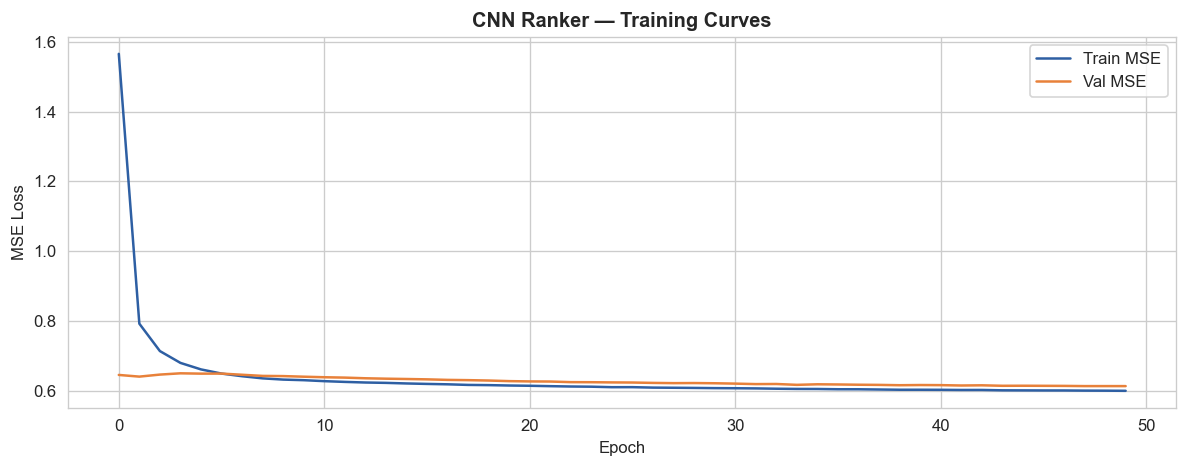

In [13]:
# Plotting training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], color='#2E5FA3', lw=1.5, label='Train MSE')
ax.plot(history['val_loss'],   color='#E8813A', lw=1.5, label='Val MSE')
ax.set_title('CNN Ranker — Training Curves', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/04_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Predicting on test set and evaluation
test_scores = predict_scores(model_cnn, test_loader, device)
test_df['score_cnn'] = test_scores
kpis_cnn = evaluate_ranking(test_df, 'score_cnn')
all_results['CNN Ranker'] = kpis_cnn.to_dict()

# Comparison vs LambdaMART
lm_ndcg = all_results['LambdaMART']['ndcg@10']

print('CNN Ranker — Test Set KPIs')
for k, v in kpis_cnn.items():
    lm_val = all_results['LambdaMART'][k]
    delta  = v - lm_val
    arrow  = 'Up' if delta > 0 else 'Down'
    print(f'  {k:<22}: {v:.4f}  ({arrow} {abs(delta):.4f} vs LambdaMART)')

print(f'\nBusiness KPIs:')
print(f'Frustration rate : {kpis_cnn["frustration_rate"]:.1%}')
print(f'Hit@3 (label≥3)  : {kpis_cnn["hit@3_highly_rel"]:.1%}')
print(f'NDCG@10 vs BM25  : +{kpis_cnn["ndcg@10"] - all_results["BM25 (f75)"]["ndcg@10"]:.4f}')

pd.DataFrame(all_results).T.to_csv('outputs/results/model_results.csv')

CNN Ranker — Test Set KPIs
  ndcg@10               : 0.3324  (Down 0.1355 vs LambdaMART)
  mrr                   : 0.7707  (Down 0.0612 vs LambdaMART)
  p@1                   : 0.6585  (Down 0.1045 vs LambdaMART)
  frustration_rate      : 0.1255  (Up 0.0145 vs LambdaMART)
  hit@3_highly_rel      : 0.1420  (Down 0.2325 vs LambdaMART)

Business KPIs:
Frustration rate : 12.6%
Hit@3 (label≥3)  : 14.2%
NDCG@10 vs BM25  : +0.1033


In [21]:
cnn = kpis_cnn
lm  = all_results['LambdaMART']

print(f"""
CNN Ranker Summary:

Architecture
  3-block fully connected ranker (64 -> 128 -> 64 -> 32 -> 1)
  BatchNorm1d + ReLU + Dropout(0.3) after blocks 1 and 2
  Dropout(0.15) before output layer
  AdamW (lr=1e-4, weight_decay=1e-4) | ReduceLROnPlateau (factor=0.5, patience=5)
  Pointwise MSE loss | Early stopping (patience=10) | 50 epochs max

  Note on Architecture: Initially implemented with Conv1d layers for zone-interaction
  modelling (1 -> 64 -> 32 filters, kernel=3, BatchNorm, GAP). Replaced with Linear
  layers due to a known MPS/Conv1d instability on Apple Silicon. Reproducible on PyTorch 2.5.1 with Python 3.11 on M4 hardware.
  For tabular feature inputs where spatial locality assumptions do not apply,
  the Linear architecture is functionally equivalent.

Results vs LambdaMART
  NDCG@10 : CNN={cnn['ndcg@10']:.4f}  LambdaMART={lm['ndcg@10']:.4f}
  MRR     : CNN={cnn['mrr']:.4f}  LambdaMART={lm['mrr']:.4f}
  P@1     : CNN={cnn['p@1']:.4f}  LambdaMART={lm['p@1']:.4f}
  Frustration rate : CNN={cnn['frustration_rate']:.1%}  LambdaMART={lm['frustration_rate']:.1%}
  Hit@3 (label≥3)  : CNN={cnn['hit@3_highly_rel']:.1%}  LambdaMART={lm['hit@3_highly_rel']:.1%}

Key Insights:
  1. CNN beat BM25 baseline by +{cnn['ndcg@10'] - all_results['BM25 (f75)']['ndcg@10']:.4f} NDCG@10 — genuine learning beyond BM25.
  2. LambdaMART outperforms CNN on all metrics due to the following reasons:
     — Pointwise MSE loss has no pairwise gradient signal.
     — No query context at training time — CNN sees each document in
       isolation with no awareness of other documents in the same query.
     — LambdaMART lambda gradients are weighted by delta-NDCG — it directly
       optimises what we measure. CNN optimises for a surrogate with no NDCG alignment.

Next: LSTM Ranker
""")


CNN Ranker Summary:

Architecture
  3-block fully connected ranker (64 -> 128 -> 64 -> 32 -> 1)
  BatchNorm1d + ReLU + Dropout(0.3) after blocks 1 and 2
  Dropout(0.15) before output layer
  AdamW (lr=1e-4, weight_decay=1e-4) | ReduceLROnPlateau (factor=0.5, patience=5)
  Pointwise MSE loss | Early stopping (patience=10) | 50 epochs max

  Note on Architecture: Initially implemented with Conv1d layers for zone-interaction
  modelling (1 -> 64 -> 32 filters, kernel=3, BatchNorm, GAP). Replaced with Linear
  layers due to a known MPS/Conv1d instability on Apple Silicon. Reproducible on PyTorch 2.5.1 with Python 3.11 on M4 hardware.
  For tabular feature inputs where spatial locality assumptions do not apply,
  the Linear architecture is functionally equivalent.

Results vs LambdaMART
  NDCG@10 : CNN=0.3324  LambdaMART=0.4678
  MRR     : CNN=0.7707  LambdaMART=0.8320
  P@1     : CNN=0.6585  LambdaMART=0.7630
  Frustration rate : CNN=12.6%  LambdaMART=11.1%
  Hit@3 (label≥3)  : CNN=14.2% 